# TP1 - Whitepatch procesamiento de Imágenes

## Nombre: Julia Stephania Maldonado Gomez a2319

---

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

%matplotlib inline

---

## Parte 1 — Algoritmo White Patch

In [4]:
def white_patch(image_bgr):

    # Convertir a float para evitar overflow
    image_float = image_bgr.astype(np.float32)
    
    # Obtener el valor máximo de cada canal
    max_b = np.max(image_float[:, :, 0])  # Canal B
    max_g = np.max(image_float[:, :, 1])  # Canal G
    max_r = np.max(image_float[:, :, 2])  # Canal R
    
    print(f"Máximos por canal -> B: {max_b:.1f} | G: {max_g:.1f} | R: {max_r:.1f}")
    
    # Escalar cada canal dividiendo por su máximo y multiplicando por 255
    corrected = image_float.copy()
    if max_b > 0:
        corrected[:, :, 0] = (image_float[:, :, 0] / max_b) * 255
    if max_g > 0:
        corrected[:, :, 1] = (image_float[:, :, 1] / max_g) * 255
    if max_r > 0:
        corrected[:, :, 2] = (image_float[:, :, 2] / max_r) * 255
    
    # Clipear y convertir de vuelta a uint8
    corrected = np.clip(corrected, 0, 255).astype(np.uint8)
    return corrected

### Carga de imágenes del /white_patch

In [5]:
imagenes_wp = [
   "wp_blue.jpg",
   "wp_green.png",
   "wp_green2.jpg",
   "wp_red.png",
   "wp_red2.jpg"
]

# Verificar que los archivos existen
for nombre in imagenes_wp:
    if os.path.exists(nombre):
        print(f"Encontrada: {nombre}")
    else:
        print(f"NO encontrada: {nombre}  <-- verificar ruta")

Encontrada: wp_blue.jpg
Encontrada: wp_green.png
Encontrada: wp_green2.jpg
Encontrada: wp_red.png
Encontrada: wp_red2.jpg


### Aplicación del algoritmo y visualización de resultados


Procesando: wp_blue.jpg
Máximos por canal -> B: 255.0 | G: 255.0 | R: 255.0


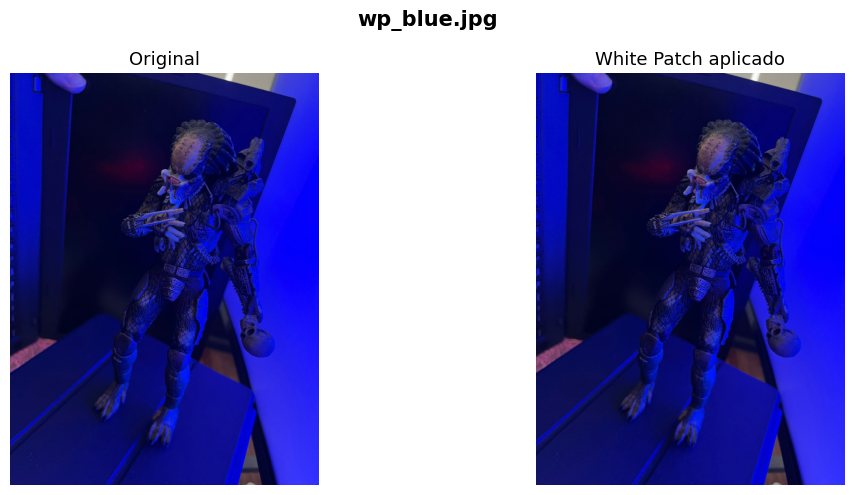


Procesando: wp_green.png
Máximos por canal -> B: 155.0 | G: 252.0 | R: 126.0


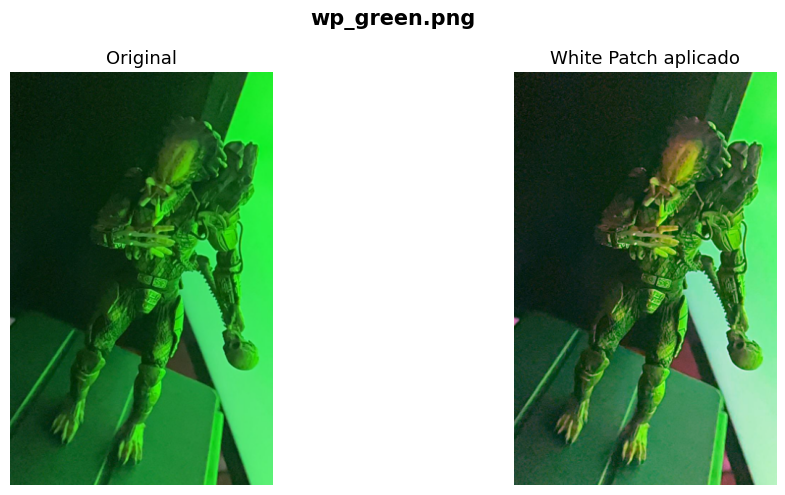


Procesando: wp_green2.jpg
Máximos por canal -> B: 172.0 | G: 255.0 | R: 170.0


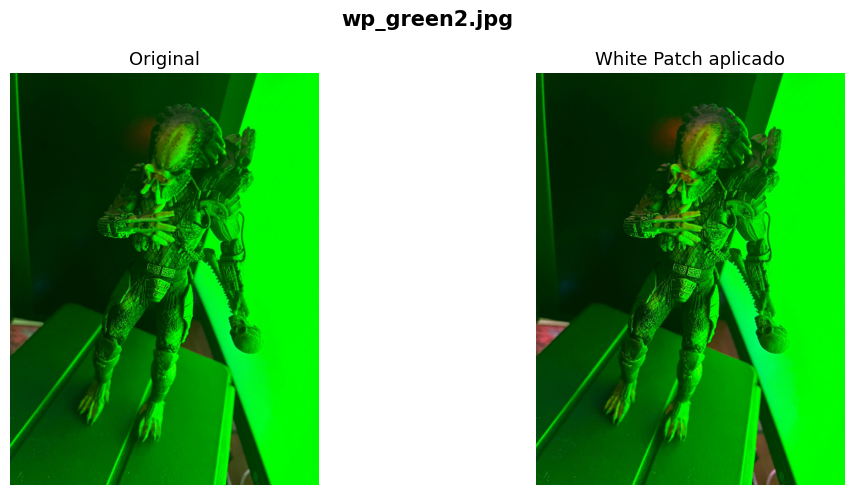


Procesando: wp_red.png
Máximos por canal -> B: 122.0 | G: 134.0 | R: 255.0


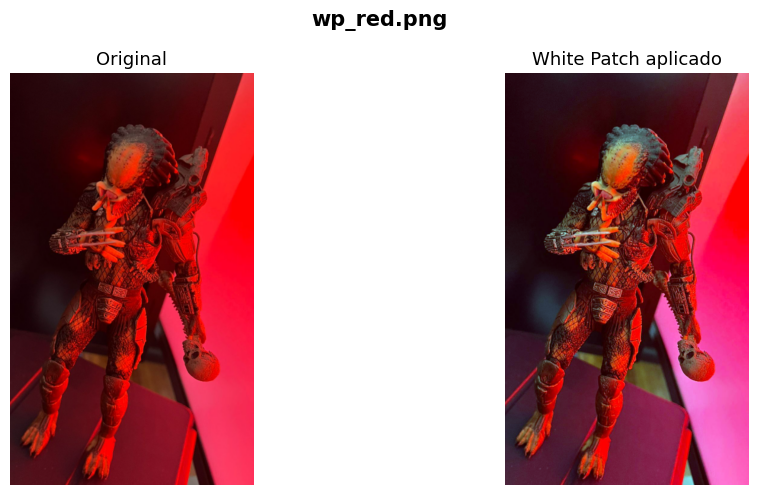


Procesando: wp_red2.jpg
Máximos por canal -> B: 203.0 | G: 201.0 | R: 255.0


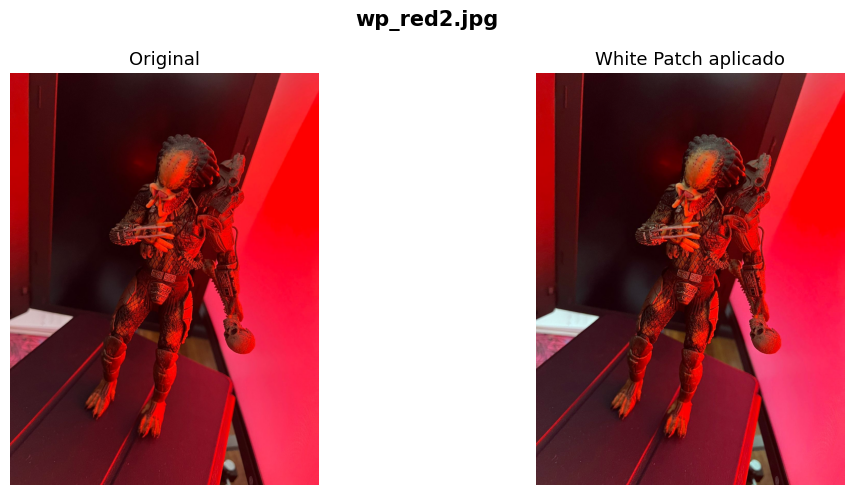

In [6]:
def mostrar_comparacion(original_bgr, corregida_bgr, titulo=""):
    """Muestra imagen original y corregida lado a lado en RGB."""
    original_rgb  = cv2.cvtColor(original_bgr,  cv2.COLOR_BGR2RGB)
    corregida_rgb = cv2.cvtColor(corregida_bgr, cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(original_rgb)
    axes[0].set_title("Original", fontsize=13)
    axes[0].axis("off")
    
    axes[1].imshow(corregida_rgb)
    axes[1].set_title("White Patch aplicado", fontsize=13)
    axes[1].axis("off")
    
    if titulo:
        fig.suptitle(titulo, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Procesar cada imagen
for nombre in imagenes_wp:
    if not os.path.exists(nombre):
        print(f"Saltando {nombre} (no encontrada)")
        continue
    
    print(f"\n{'='*50}")
    print(f"Procesando: {nombre}")
    
    img = cv2.imread(nombre)
    img_corregida = white_patch(img)
    mostrar_comparacion(img, img_corregida, titulo=nombre)

### Análisis de posibles fallas del algoritmo White Patch

El algoritmo White Patch es simple y rápido, pero presenta limitaciones importantes:

1. **Suposición incorrecta del máximo:** Asume que el píxel más brillante en cada canal es un blanco perfecto. Si la imagen no contiene una superficie verdaderamente blanca, la corrección será errónea.

2. **Sensibilidad a píxeles saturados o ruido:** Un solo píxel con valor muy alto por ruido o reflexión especular puede dominar el cálculo del máximo, produciendo una imagen sub-corregida.

3. **Escenas con dominante intencional:** En imágenes con iluminación cálida (atardeceres, velas), el algoritmo elimina el color que forma parte del contenido artístico de la escena.

4. **Pérdida de detalle en los canales:** Al dividir por el máximo, canales con poca energía se amplifican excesivamente, introduciendo ruido en esas regiones.

5. **No considera la distribución espacial:** Al usar únicamente el valor máximo global, ignora información contextual sobre qué regiones corresponden realmente a superficies blancas.

---

## Parte 2 — Histogramas en escala de grises

### 2.1 — Lectura y visualización en escala de grises

img1 — shape: (288, 287) | dtype: uint8
img2 — shape: (288, 287) | dtype: uint8


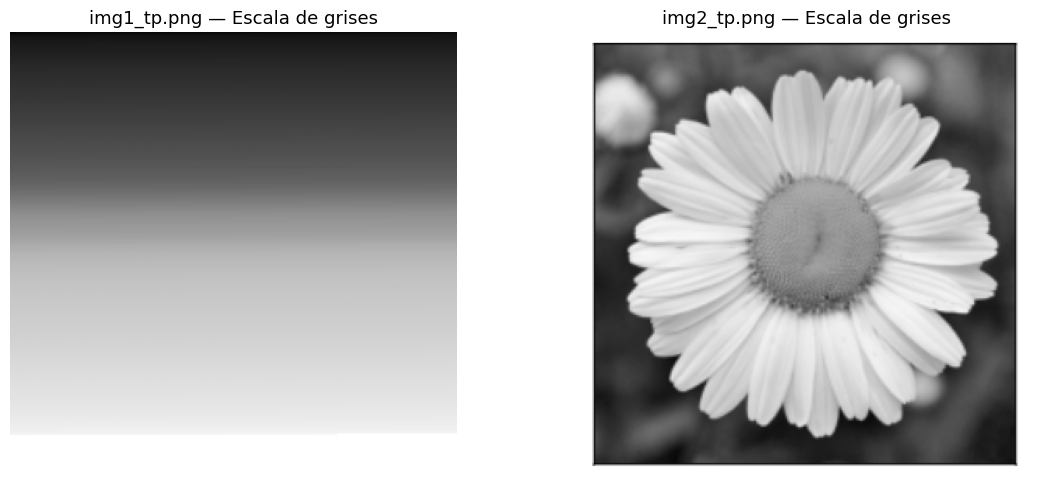

In [7]:
RUTA_IMG1 = "img1_tp.png"  
RUTA_IMG2 = "img2_tp.png"   

# Leer en escala de grises directamente con OpenCV
img1_gray = cv2.imread(RUTA_IMG1, cv2.IMREAD_GRAYSCALE)
img2_gray = cv2.imread(RUTA_IMG2, cv2.IMREAD_GRAYSCALE)

# Verificar que se cargaron correctamente
assert img1_gray is not None, f"No se pudo cargar {RUTA_IMG1}. Verificar la ruta."
assert img2_gray is not None, f"No se pudo cargar {RUTA_IMG2}. Verificar la ruta."

print(f"img1 — shape: {img1_gray.shape} | dtype: {img1_gray.dtype}")
print(f"img2 — shape: {img2_gray.shape} | dtype: {img2_gray.dtype}")

# Visualizar ambas imágenes en escala de grises
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img1_gray, cmap="gray")
axes[0].set_title("img1_tp.png — Escala de grises", fontsize=13)
axes[0].axis("off")

axes[1].imshow(img2_gray, cmap="gray")
axes[1].set_title("img2_tp.png — Escala de grises", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 2.2 — Elección del número de bins y generación de histogramas

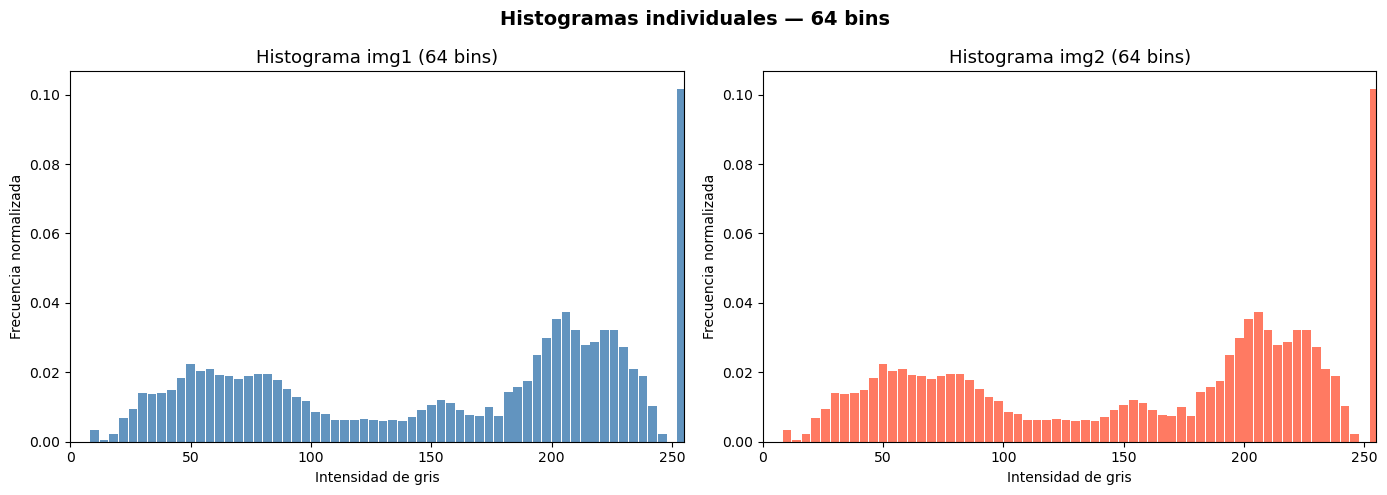

In [ ]:

NUM_BINS = 64

# Calcular histogramas con numpy
hist1, bin_edges1 = np.histogram(img1_gray.ravel(), bins=NUM_BINS, range=(0, 256))
hist2, bin_edges2 = np.histogram(img2_gray.ravel(), bins=NUM_BINS, range=(0, 256))

# Normalizar para comparación justa 
hist1_norm = hist1 / hist1.sum()
hist2_norm = hist2 / hist2.sum()

bin_centers = (bin_edges1[:-1] + bin_edges1[1:]) / 2  

# Graficar histogramas individuales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(bin_centers, hist1_norm, width=(256/NUM_BINS)*0.9,
            color="steelblue", edgecolor="none", alpha=0.85)
axes[0].set_title(f"Histograma img1 ({NUM_BINS} bins)", fontsize=13)
axes[0].set_xlabel("Intensidad de gris")
axes[0].set_ylabel("Frecuencia normalizada")
axes[0].set_xlim(0, 255)

axes[1].bar(bin_centers, hist2_norm, width=(256/NUM_BINS)*0.9,
            color="tomato", edgecolor="none", alpha=0.85)
axes[1].set_title(f"Histograma img2 ({NUM_BINS} bins)", fontsize=13)
axes[1].set_xlabel("Intensidad de gris")
axes[1].set_ylabel("Frecuencia normalizada")
axes[1].set_xlim(0, 255)

plt.suptitle(f"Histogramas individuales — {NUM_BINS} bins", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.3 — Comparación de histogramas (superposición)

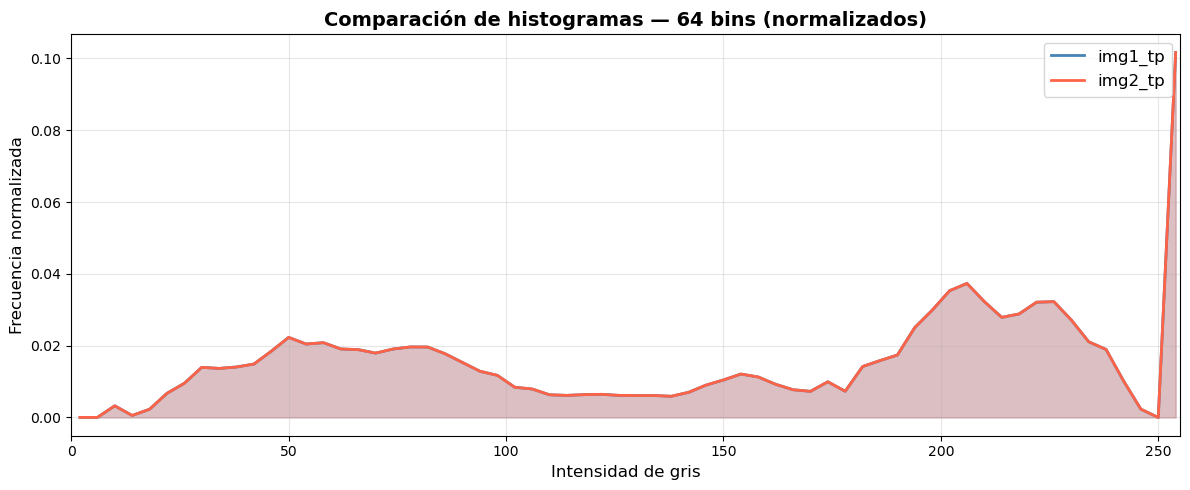


Estadísticas de intensidad:
img1 — Media: 154.81 | Std: 75.34 | Min: 2 | Max: 255
img2 — Media: 154.81 | Std: 75.34 | Min: 2 | Max: 255


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(bin_centers, hist1_norm, color="steelblue", linewidth=2, label="img1_tp")
ax.plot(bin_centers, hist2_norm, color="tomato",    linewidth=2, label="img2_tp")
ax.fill_between(bin_centers, hist1_norm, alpha=0.25, color="steelblue")
ax.fill_between(bin_centers, hist2_norm, alpha=0.25, color="tomato")

ax.set_title(f"Comparación de histogramas — {NUM_BINS} bins (normalizados)", fontsize=14, fontweight="bold")
ax.set_xlabel("Intensidad de gris", fontsize=12)
ax.set_ylabel("Frecuencia normalizada", fontsize=12)
ax.set_xlim(0, 255)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas básicas de cada imagen
print("\nEstadísticas de intensidad:")
print(f"img1 — Media: {img1_gray.mean():.2f} | Std: {img1_gray.std():.2f} | "
      f"Min: {img1_gray.min()} | Max: {img1_gray.max()}")
print(f"img2 — Media: {img2_gray.mean():.2f} | Std: {img2_gray.std():.2f} | "
      f"Min: {img2_gray.min()} | Max: {img2_gray.max()}")

### 2.4 — Análisis y observaciones

**¿Qué se observa al comparar los histogramas?**

- **Distribución de intensidades:** Describir si alguna imagen es más oscura/clara que la otra según la posición del pico en el histograma.
- **Contraste:** Una distribución más amplia (mayor desviación estándar) indica mayor contraste. Comparar los valores de `Std` impresos arriba.
- **Similitudes/diferencias:** Si los histogramas se superponen casi completamente, las imágenes tienen distribuciones tonales similares aunque su contenido visual pueda diferir.

---

### 2.5 — ¿Son útiles los histogramas como *features* para clasificación/detección?

**Sí, los histogramas de grises son una herramienta clásica y útil como features**, especialmente en modelos tradicionales de clasificación de imágenes.

**Ventajas como features:**
- **Invarianza a la posición:** El histograma resume la distribución global de intensidades sin importar dónde están los objetos en la imagen. Esto es útil cuando la posición del objeto no es relevante para la clase.
- **Compacto y eficiente:** Un histograma de 64 bins es un vector de 64 números, mucho más pequeño que los miles de píxeles originales. Reduce la dimensionalidad sin pérdida excesiva de información.
- **Discriminativo para ciertas clases:** Imágenes de distintas categorías suelen tener distribuciones de intensidad características (ej. imágenes de radiografías vs. imágenes de naturaleza).
- **Robusto a pequeñas transformaciones:** Es relativamente robusto ante rotaciones y traslaciones menores.

**Limitaciones:**
- **Pierde información espacial:** Dos imágenes completamente distintas pueden tener histogramas muy similares si tienen la misma distribución de grises.
- **No captura texturas ni formas:** Para tareas donde la estructura espacial es clave (detección de objetos, reconocimiento facial), el histograma global es insuficiente por sí solo.

**Conclusión:** Como feature único puede ser suficiente para tareas simples de clasificación (ej. distinguir imágenes oscuras de claras, o categorías con distribuciones tonales muy distintas). En modelos más complejos, conviene combinarlos con otros descriptores (HOG, LBP, features de CNN) para mejorar la capacidad discriminativa.